# Clasificación automática de textos según los Objetivos de Desarrollo Sostenible (ODS) con *machine learning* no supervisado

**Microproyecto 2 — Maestría en Inteligencia Artificial (MLNS)**

---

**Objetivo:** desarrollar una solución basada en técnicas de procesamiento de lenguaje natural y *machine learning* que permita clasificar automáticamente un texto según los 17 Objetivos de Desarrollo Sostenible (ODS) de la Agenda 2030, facilitando la interpretación y el análisis de información textual proveniente de procesos de planeación participativa.


**Enfoque general del método:**

1. Cargar y explorar el conjunto de datos (`Datos_textosODS.xlsx`), revisando la distribución de clases, longitud de los textos y calidad de los datos (nulos, duplicados).
2. Preprocesar los textos en español y construir un *pipeline* de representación mediante bolsa de palabras (BOW) con ponderación TF-IDF.
3. Aplicar SVD truncado (`TruncatedSVD`) sobre la matriz TF-IDF para obtener un modelo de tópicos (LSA), explorando entre 10 y 20 componentes e interpretando cualitativamente al menos 5 de ellos frente a los ODS.
4. Construir un modelo de clasificación sobre la representación reducida, con búsqueda de hiperparámetros, justificando el algoritmo y las métricas empleadas.
5. Evaluar el modelo sobre un conjunto de test no utilizado durante el entrenamiento, mostrando la predicción para al menos cuatro textos.
6. *(Opcional)* Desplegar el modelo entrenado en una aplicación interactiva con Streamlit.

## 1. Importación de librerías

Se agrupan las librerías por función para mantener el notebook ordenado:

- **Manejo de datos y archivos:** `pandas`, `numpy`.
- **Preprocesamiento de texto:** `re`, `nltk` (stopwords y stemmer en español).
- **Visualización:** `matplotlib`, `seaborn`.
- **Modelado — representación y reducción de dimensionalidad:** `TfidfVectorizer`, `TruncatedSVD` de scikit-learn.
- **Modelado — clasificación y evaluación:** `train_test_split`, `GridSearchCV`, `LogisticRegression`, `classification_report`, `confusion_matrix` de scikit-learn.
- **Persistencia:** `joblib`.

In [1]:
# 1. IMPORTAR LIBRERIAS

In [2]:
import pandas as pd

In [3]:
import numpy as np

In [4]:
import re

In [5]:
import nltk

In [6]:
import matplotlib.pylab as plt

In [7]:
import seaborn as sns

In [8]:
import joblib

In [318]:
import os

In [9]:
from nltk.corpus import stopwords

In [10]:
from nltk.stem import SnowballStemmer

In [11]:
from sklearn.feature_extraction.text import TfidfTransformer

In [12]:
from sklearn.decomposition import TruncatedSVD

In [13]:
from sklearn.model_selection import train_test_split, GridSearchCV

In [14]:
from sklearn.linear_model import LogisticRegression

In [15]:
from sklearn.metrics import classification_report, confusion_matrix

In [16]:
from langdetect import detect, LangDetectException

In [17]:
from nltk.tokenize import word_tokenize

In [18]:
from nltk import RegexpTokenizer

In [19]:
from wordcloud import WordCloud

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [21]:
from gensim.corpora import Dictionary

In [22]:
from gensim.models.coherencemodel import CoherenceModel

In [23]:
from sklearn.neighbors import NearestNeighbors

In [24]:
from scipy.sparse import csr_matrix

In [25]:
from scipy.sparse.csgraph import connected_components

In [26]:
from sklearn.model_selection import StratifiedGroupKFold

In [27]:
from sklearn.pipeline import Pipeline

In [28]:
from sklearn.ensemble import RandomForestClassifier

In [29]:
from sklearn.svm import LinearSVC

In [30]:
from scipy.cluster.hierarchy import linkage, leaves_list

In [325]:
from preprocesamiento import preprocess_text as preprocess_text_modulo

In [31]:
# 1.2.1 Definimos el diccionario de nombres oficiales de los ODS

In [32]:
NOMBRES_ODS = {
    1: "Fin de la pobreza",
    2: "Hambre cero",
    3: "Salud y bienestar",
    4: "Educación de calidad",
    5: "Igualdad de género",
    6: "Agua limpia y saneamiento",
    7: "Energía asequible y no contaminante",
    8: "Trabajo decente y crecimiento económico",
    9: "Industria, innovación e infraestructura",
    10: "Reducción de las desigualdades",
    11: "Ciudades y comunidades sostenibles",
    12: "Producción y consumo responsables",
    13: "Acción por el clima",
    14: "Vida submarina",
    15: "Vida de ecosistemas terrestres",
    16: "Paz, justicia e instituciones sólidas",
    17: "Alianzas para lograr los objetivos",
}

## 2. Carga y exploración de datos

Antes de construir el pipeline de clasificación por ODS necesitamos entender la calidad y las características del conjunto de datos: esto determina decisiones concretas del preprocesamiento (sección 3) y del modelado (sección 4), como el uso de `stratify` en el split o los umbrales de `min_df`/`max_df` en TF-IDF.

### 2.1 Carga de datos

Cargamos el archivo `Datos_textosODS.xlsx`, que contiene los textos ya traducidos al español y etiquetados con su ODS correspondiente (ver sección 2.5 sobre el origen de estos datos).

In [33]:
# 2.1.1 guardar ruta de datos

In [34]:
root = "data/_94f47dfe96414485b5def55bccbd7cb8_Datos_textosODS.xlsx"

In [35]:
# 2.1.2 leer los datos del excel

In [36]:
data = pd.read_excel(root)

In [37]:
data.head()

,textos,ODS
0,"""Aprendizaje"" y ""educación"" se consideran sinó...",4
1,No dejar clara la naturaleza de estos riesgos ...,6
2,"Como resultado, un mayor y mejorado acceso al ...",13
3,Con el Congreso firmemente en control de la ju...,16
4,"Luego, dos secciones finales analizan las impl...",5


In [38]:
# Nota: el archivo tiene exactamente las dos columnas esperadas (`textos`, `ODS`), sin columnas adicionales que limpiar.

### 2.2 Tratamiento de nulos y duplicados

Exploraremos el dataset y revisaremos la cantidad de datos nulos y duplicados en el conjunto, verificando la integridad básica del conjunto antes de cualquier transformación:

In [39]:
# 2.2.1 Revisamos los datos nulos del dataset

In [40]:
print(f'Datos nulos:\n{data.isna().sum()}')

Datos nulos:
textos    0
ODS       0
dtype: int64


In [41]:
# 2.2.2 Revisamos los datos duplicados del dataset

In [42]:
print(f'\nDatos duplicados: {data.duplicated().sum()}')


Datos duplicados: 0


In [43]:
# 2.2.3 Eliminamos datos nulos y duplicados y verificamos el tamaño resultante

In [44]:
data.dropna(inplace=True)

In [45]:
data.drop_duplicates(inplace=True)

In [46]:
data.shape

(9656, 2)

In [47]:
# Nota: Aunque desde la revisión vimos que no teníamos nulos ni duplicados se deja
#       realizado el proceso por si el dataset cambia en algun momento futuro.

### 2.3 Distribución de la variable objetivo

Revisamos cómo se distribuyen los textos entre los 17 ODS, porque el balance (o desbalance) de clases condiciona directamente cómo dividimos el conjunto en train/test y cómo evaluamos el modelo de clasificación.

In [48]:
# 2.3.1 Contamos la cantidad de textos por cada ODS

In [49]:
ods_counts = data['ODS'].value_counts()

In [50]:
ods_counts

ODS
16    1080
5     1070
4     1025
3      894
7      787
6      695
11     607
1      505
13     464
8      446
14     377
2      369
10     352
9      343
15     330
12     312
Name: count, dtype: int64

In [51]:
# 2.3.2 Visualizamos la distribución

<Axes: xlabel='ODS'>

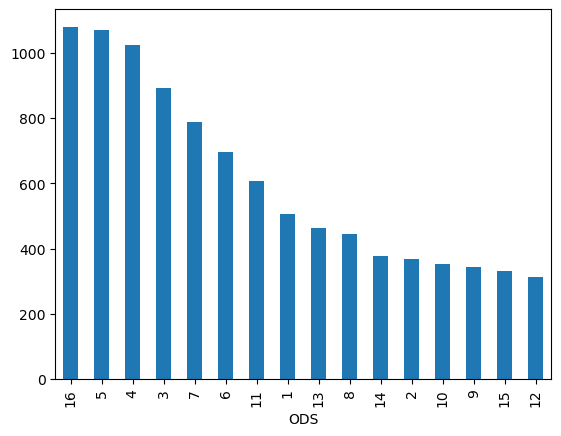

In [52]:
ods_counts.plot(kind='bar')

In [53]:
# Nota: La distribución va de 312 (ODS 12) a 1.080 (ODS 16) textos desbalance moderado, no extremo. 
#       Esto justifica usar stratify=data['ODS'] al hacer el train_test_split en la sección 4, 
#       para que cada clase mantenga su proporción en train y test. Además, 
#       el ODS 17 no aparece en ningún texto: el modelo que construyamos solo podrá predecir 16 de los 17 ODS, 
#       una limitación del dataset que dejamos documentada aquí para no tener que justificarla de nuevo en la evaluación final.

### 2.4 Longitud de los textos

Revisamos la longitud de los textos en caracteres. Esto nos sirve para justificar más adelante los parámetros `min_df`/`max_df` de `TfidfVectorizer` y para detectar textos demasiado cortos o largos que puedan ser ruido antes de vectorizar.

**Lectura de 2.4:** la longitud va de 143 a 1.977 caracteres (promedio 709, mediana 669). No hay textos extremadamente cortos que queden casi vacíos tras quitar stopwords, ni textos desproporcionadamente largos que puedan dominar el vocabulario. Por eso no filtramos por longitud; usamos este rango como referencia al fijar `min_df`/`max_df` en la sección 3.

In [54]:
# 2.4.1 Calculamos la longitud de cada texto

In [55]:
data['longitud'] = data['textos'].str.len()

In [56]:
# 2.4.2 Revisamos estadísticas descriptivas de la longitud

In [57]:
data['longitud'].describe()

count    9656.000000
mean      708.952465
std       238.864636
min       143.000000
25%       522.000000
50%       669.000000
75%       864.000000
max      1977.000000
Name: longitud, dtype: float64

In [58]:
# 2.4.3 Visualizamos la distribución de la longitud

(array([  3.,   3.,   7.,   9.,  56., 201., 329., 479., 514., 594., 623.,
        616., 622., 585., 540., 527., 464., 453., 389., 354., 349., 268.,
        247., 246., 222., 193., 172., 180., 103.,  81.,  66.,  47.,  37.,
         29.,  25.,  10.,   5.,   2.,   3.,   1.,   1.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   1.]),
 array([ 143.  ,  179.68,  216.36,  253.04,  289.72,  326.4 ,  363.08,
         399.76,  436.44,  473.12,  509.8 ,  546.48,  583.16,  619.84,
         656.52,  693.2 ,  729.88,  766.56,  803.24,  839.92,  876.6 ,
         913.28,  949.96,  986.64, 1023.32, 1060.  , 1096.68, 1133.36,
        1170.04, 1206.72, 1243.4 , 1280.08, 1316.76, 1353.44, 1390.12,
        1426.8 , 1463.48, 1500.16, 1536.84, 1573.52, 1610.2 , 1646.88,
        1683.56, 1720.24, 1756.92, 1793.6 , 1830.28, 1866.96, 1903.64,
        1940.32, 1977.  ]),
 <BarContainer object of 50 artists>)

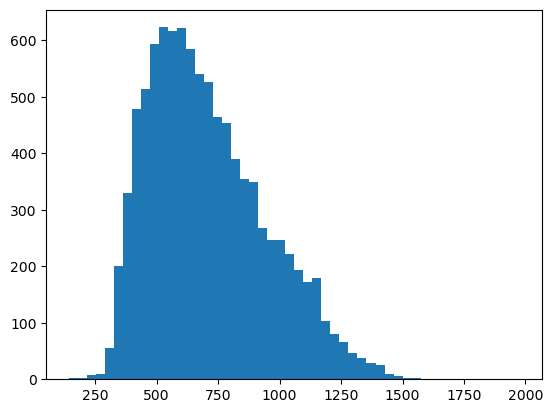

In [59]:
plt.hist(data['longitud'], bins=50)

### 2.5 Consideraciones sobre el origen de los datos

El enunciado indica que los textos fueron traducidos con DeepL y que el conjunto se amplió con textos generados por la API de ChatGPT. Verificamos si esto dejó rastros detectables: errores de codificación de la traducción o fragmentos que quedaron sin traducir, ya que un texto mal traducido no se beneficia del preprocesamiento en español que construiremos en la sección 3 (`stopwords` y `SnowballStemmer` en español no le sirven a un texto en otro idioma).


**Lectura de 2.5:** de 9.656 textos, solo 1 (índice 5112, en portugués) es un caso genuino de idioma incorrecto y se elimina. Los otros tres casos con señales de inglés (1395, 3713, 977, 7560 es decir cuatro en total) resultan ser citas bibliográficas sin traducir dentro de textos que sí están en español, y se conservan. El dataset queda en 9.655 filas, consistente en español y listo para que `stopwords.words('spanish')` y `SnowballStemmer('spanish')` operen correctamente sobre prácticamente la totalidad del corpus.

In [60]:
# 2.5.1 Descargamos las stopwords en inglés para el chequeo de residuos de traducción

In [61]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\alexc\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [62]:
# 2.5.2 Nos quedamos solo con las palabras exclusivas del inglés (sin solapamiento con español)

In [63]:
spanish_stopwords = set(stopwords.words('spanish'))

In [64]:
english_only = set(stopwords.words('english')) - spanish_stopwords

In [65]:
# 2.5.3 Revisamos si hay caracteres típicos de errores de codificación (mojibake)

In [66]:
patron_mojibake = r'[ÃÂ][€™¢£¥©]?|�'

In [67]:
data['textos'].str.contains(patron_mojibake, regex=True).sum()

np.int64(0)

In [68]:
# 2.5.4 Calculamos la proporción de palabras exclusivas del inglés por texto

In [69]:
def proporcion_palabras_ingles(texto):
    palabras = texto.lower().split()
    if not palabras:
        return 0
    en_ingles = sum(1 for p in palabras if p in english_only)
    return en_ingles / len(palabras)

In [70]:
data['prop_ingles'] = data['textos'].apply(proporcion_palabras_ingles)
data['prop_ingles'].describe()

count    9656.000000
mean        0.000613
std         0.004315
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         0.117647
Name: prop_ingles, dtype: float64

In [71]:
# 2.5.5 Revisamos los textos con mayor proporción de palabras exclusivas del inglés

In [72]:
data.sort_values('prop_ingles', ascending=False)[['textos', 'ODS', 'prop_ingles']].head(5)

,textos,ODS,prop_ingles
977,The Challenge of Hunger: Focus on Financial Cr...,1,0.117647
4250,1. 1. Introducción: Examen crítico de la Resol...,16,0.109756
238,Se dice que cualquier persona cuyos ingresos s...,1,0.102564
7560,Tajik women in labour migration: forced tactic...,5,0.088889
9146,Ginebra: Unión Internacional de Telecomunicaci...,3,0.074074


In [73]:
# 2.5.6 Definimos una función que detecta el idioma de cada texto

In [74]:
def detectar_idioma(texto):
    try:
        return detect(texto)
    except LangDetectException:
        return 'desconocido'

In [75]:
# 2.5.7 Detectamos el idioma de cada texto del conjunto

In [76]:
data['idioma'] = data['textos'].apply(detectar_idioma)

In [77]:
# 2.5.8 Contamos cuántos textos hay por idioma detectado

In [78]:
data['idioma'].value_counts()

idioma
es    9655
pt       1
Name: count, dtype: int64

In [79]:
# 2.5.9 Revisamos los textos que no fueron detectados como español

In [80]:
data[data['idioma'] != 'es']

,textos,ODS,longitud,prop_ingles,idioma
5112,Espera-se que os países predicados Vanuatu e A...,9,614,0.030928,pt


In [81]:
for idx in [3713, 5112]:
    print(f"--- índice {idx} (idioma detectado: {data.loc[idx, 'idioma']}) ---")
    print(data.loc[idx, 'textos'])
    print()

--- índice 3713 (idioma detectado: es) ---
Ambiente finlandés (2009), Towards a Recycling Society - the National Waste Plan for 2016. Ministerio de Medio Ambiente de Finlandia - Página web sobre políticas de residuos

--- índice 5112 (idioma detectado: pt) ---
Espera-se que os países predicados Vanuatu e Angola se graduem nos anos 2020 e 2021, respectivamente. A ONU incluiu as necessidades dos PMA (Países Menos Avançados) nas suas atividades e programas, sendo a Oficina do Alto Representante das Nacoes Unidais para os PMA (ONU-PMA) uma entidade especializada que presta apoio em um nível especial. O Programa de Acao de Estambul (PAI) 2011-2020 foi adoptado na Quarta Conferencia das Nacoes Unidas sobre os PMA em Estambul, em 2011, para poder ajudar os PMA ao desenvolvimento sustentavel. Nas prioridades de infraestutura para os PMA, estão incluidas as Tecnologias de



In [82]:
# 2.5.10 Revisamos el texto completo y el idioma detectado de los casos 977 y 7560

In [83]:
for idx in [977, 7560]:
    print(f"--- índice {idx} (idioma detectado: {data.loc[idx, 'idioma']}) ---")
    print(data.loc[idx, 'textos'])
    print()

--- índice 977 (idioma detectado: es) ---
The Challenge of Hunger: Focus on Financial Crisis and Gender Inequality, Instituto Internacional de Investigación sobre Políticas Alimentarias/Welthungerhilfe/Concem Worldwide, Bonn/Dublín/Washington DC. Proporcionar cobertura en tiempos de crisis y más allá, Organización Internacional del Trabajo, Ginebra. Electricity Sector Reforms and the Poor in Europe and Central Asia, Banco Mundial, Washington DC. Recesión, recuperación y reforma en Europa central y oriental y la antigua Unión Soviética, Banco Mundial, Washington DC.

--- índice 7560 (idioma detectado: es) ---
Tajik women in labour migration: forced tactics of survival or choice of emancipated women]. Globalizando el "postsocialismo": madres móviles y neoliberalismo en los márgenes de Europa. Desigualdades de género en los mercados laborales de Asia Central. Disponible en www.eurasia.undp.org/content/dam/ rbec / docs / Gender%20inequalities%20in%201abour%20markets% 20in%20Central%20Asia.

In [84]:
# 2.5.11 Eliminamos únicamente el texto que está completamente en otro idioma (fila 5112)

In [85]:
data = data.drop(index=5112).reset_index(drop=True)
data.shape

(9655, 5)

### 2.6 Normalización de espacios

Revisamos si quedaron artefactos de formato (espacios dobles, saltos de línea, espacios al inicio o final) que suelen quedar de la extracción o traducción automática del texto, y los limpiamos antes de pasar al preprocesamiento.

**Lectura de 2.6:** encontramos artefactos de formato en una fracción pequeña del conjunto (305 textos con espacios sobrantes al inicio/final, 22 con espacios dobles, 3 con saltos de línea), probablemente restos de la extracción del texto original o de la traducción automática. Aunque el tokenizador de la sección 3 los habría ignorado de todas formas, los normalizamos aquí para mantener el dataset limpio y recalculamos `longitud` para que siga siendo consistente con el texto ya limpio.

In [86]:
# 2.6.1 Revisamos si hay espacios dobles, saltos de línea o espacios al inicio/final

In [87]:
tiene_espacios_dobles = data['textos'].str.contains(r'\s{2,}', regex=True).sum()
tiene_saltos_linea = data['textos'].str.contains(r'\n', regex=True).sum()
tiene_espacios_extremos = (data['textos'] != data['textos'].str.strip()).sum()

print(f'Espacios dobles: {tiene_espacios_dobles}')
print(f'Saltos de línea: {tiene_saltos_linea}')
print(f'Espacios al inicio/final: {tiene_espacios_extremos}')

Espacios dobles: 22
Saltos de línea: 3
Espacios al inicio/final: 305


In [88]:
# 2.6.2 Normalizamos los espacios: quitamos los del inicio/final y colapsamos los múltiples

In [89]:
data['textos'] = data['textos'].str.strip()
data['textos'] = data['textos'].str.replace(r'\s+', ' ', regex=True)

In [90]:
# 2.6.3 Verificamos que ya no queden estos artefactos

In [91]:
print(f"Espacios dobles: {data['textos'].str.contains(r'\s{{2,}}', regex=True).sum()}")
print(f"Saltos de línea: {data['textos'].str.contains(r'\n', regex=True).sum()}")
print(f"Espacios al inicio/final: {(data['textos'] != data['textos'].str.strip()).sum()}")

Espacios dobles: 0
Saltos de línea: 0
Espacios al inicio/final: 0


In [92]:
# 2.6.4 Volvemos a calcular la longitud del texto, ya que en 2.4 se calculó antes de quitar los espacios de más

In [93]:
data['longitud'] = data['textos'].str.len()

## 3. Procesamiento de texto y representación TF-IDF

El objetivo de esta sección es transformar cada texto en un vector numérico donde las palabras que distinguen a un ODS de otro pesen más que las palabras genéricas que aparecen por igual en cualquier texto. Esta representación es la que alimentará el modelo de tópicos (sección 4) y el clasificador (sección 5) que finalmente decidirá a qué ODS pertenece cada texto.

### 3.1 Recursos de NLTK
Los textos ya están en español (sección 2.5), así que necesitamos herramientas específicas de este idioma. Usar por error stopwords o un stemmer en inglés dejaría intacta la mayoría del vocabulario relevante para los ODS y filtraría mal, contaminando la señal que el modelo necesita para diferenciar categorías.

In [94]:
# 3.1.1 Descargamos el tokenizador

In [95]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\alexc\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [96]:
# 3.1.2 Descargamos las tablas adicionales del tokenizador

In [97]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\alexc\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [98]:
# 3.1.3 Convertimos todo el texto a minúsculas antes de tokenizar

In [99]:
data['textos'] = data['textos'].str.lower()

### 3.2 Tokenización

Separamos cada texto en palabras individuales porque el modelo va a aprender a asociar palabras específicas con ODS específicos (por ejemplo, "pobreza" con el ODS 1, "género" con el ODS 5). Mientras el texto esté completo como una sola cadena, no hay unidades que el modelo pueda relacionar con una categoría.

In [100]:
# 3.2.1 Tokenizamos cada texto

In [101]:
tokenized = data['textos'].apply(lambda x: word_tokenize(x, language='spanish'))

In [102]:
tokenized.iloc[0]

['``',
 'aprendizaje',
 "''",
 'y',
 '``',
 'educación',
 "''",
 'se',
 'consideran',
 'sinónimos',
 'de',
 'escolarización',
 'formal',
 '.',
 'las',
 'organizaciones',
 'auxiliares',
 ',',
 'como',
 'las',
 'editoriales',
 'de',
 'educación',
 ',',
 'las',
 'juntas',
 'examinadoras',
 'y',
 'las',
 'organizaciones',
 'de',
 'formación',
 'de',
 'docentes',
 ',',
 'se',
 'consideran',
 'extensiones',
 'de',
 'los',
 'acuerdos',
 'establecidos',
 'por',
 'los',
 'gobiernos',
 '.',
 'este',
 'marco',
 'de',
 'comprensión',
 'se',
 'ha',
 'vuelto',
 'cada',
 'vez',
 'más',
 'inadecuado',
 '.']

In [103]:
# 3.2.2 Tokenizamos conservando solo palabras (sin puntuación)

In [104]:
tokenizer = RegexpTokenizer(r'\w+')

In [105]:
tokenized_no_punct = data['textos'].apply(lambda x: tokenizer.tokenize(x))

In [106]:
tokenized_no_punct.iloc[0]

['aprendizaje',
 'y',
 'educación',
 'se',
 'consideran',
 'sinónimos',
 'de',
 'escolarización',
 'formal',
 'las',
 'organizaciones',
 'auxiliares',
 'como',
 'las',
 'editoriales',
 'de',
 'educación',
 'las',
 'juntas',
 'examinadoras',
 'y',
 'las',
 'organizaciones',
 'de',
 'formación',
 'de',
 'docentes',
 'se',
 'consideran',
 'extensiones',
 'de',
 'los',
 'acuerdos',
 'establecidos',
 'por',
 'los',
 'gobiernos',
 'este',
 'marco',
 'de',
 'comprensión',
 'se',
 'ha',
 'vuelto',
 'cada',
 'vez',
 'más',
 'inadecuado']

### 3.3 Eliminación de palabras vacías

Palabras como "el", "de", "para" aparecen con frecuencia similar en textos de los 17 ODS que no ayudan a diferenciar un ODS de otro, y si no las trabajamos, le restan peso relativo a las palabras que sí cargan esa información en la matriz TF-IDF. Quitarlas concentra el vocabulario en los términos que realmente sirven para clasificar.

In [107]:
# 3.3.1 Cargamos las stopwords en español

In [108]:
nltk_stopwords = stopwords.words('spanish')

In [109]:
# 3.3.2 Filtramos las palabras vacías de cada texto

In [110]:
no_stopwords = tokenized_no_punct.apply(lambda x: [token for token in x if token not in nltk_stopwords])

In [111]:
no_stopwords.iloc[0]

['aprendizaje',
 'educación',
 'consideran',
 'sinónimos',
 'escolarización',
 'formal',
 'organizaciones',
 'auxiliares',
 'editoriales',
 'educación',
 'juntas',
 'examinadoras',
 'organizaciones',
 'formación',
 'docentes',
 'consideran',
 'extensiones',
 'acuerdos',
 'establecidos',
 'gobiernos',
 'marco',
 'comprensión',
 'vuelto',
 'cada',
 'vez',
 'inadecuado']

In [112]:
# 3.3.3 Comparamos el tamaño del vocabulario antes y después de quitar stopwords

In [113]:
vocab_antes = set(word for tokens in tokenized_no_punct for word in tokens)

In [114]:
vocab_despues = set(word for tokens in no_stopwords for word in tokens)

In [115]:
print(f'Vocabulario antes de quitar stopwords: {len(vocab_antes)}')

Vocabulario antes de quitar stopwords: 34814


In [116]:
print(f'Vocabulario después de quitar stopwords: {len(vocab_despues)}')

Vocabulario después de quitar stopwords: 34630


In [117]:
# Nota: Poner el texto en minúsculas antes de tokenizar redujo el vocabulario de 38.575 a 34.814 palabras (−3.761), 
#       al fusionar duplicados como "Educación"/"educación" en una sola entrada, esto es lo que evita que el TF-IDF 
#       divida la señal de una misma palabra en dos columnas distintas. La eliminación de stopwords, por su parte, 
#       solo retira 184 palabras adicionales .
#       
#       34.814 a 34.630: Es un número bajo porque la mayoría de las ~313 stopwords en 
#       español de NLTK son formas verbales poco frecuentes en el registro formal de estos textos informes, políticas públicas,
#       no porque el filtro esté fallando.

### 3.4 Nube de palabras

Revisamos visualmente si lo que queda del vocabulario realmente tiene que ver con los ODS. Si la nube muestra palabras como "pobreza", "género", "ambiente" o "salud", confirma que el preprocesamiento está reteniendo justo el tipo de vocabulario que el clasificador va a necesitar para diferenciar categorías.

In [118]:
# 3.4.1 Concatenamos todas las palabras en un solo string

In [119]:
wc_text = ' '.join(word for text in no_stopwords for word in text)

In [120]:
# 3.4.2 Construimos la nube de palabras

In [121]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    min_font_size=10,
    max_font_size=110
).generate(wc_text)

In [122]:
# 3.4.3 Visualizamos la nube de palabras

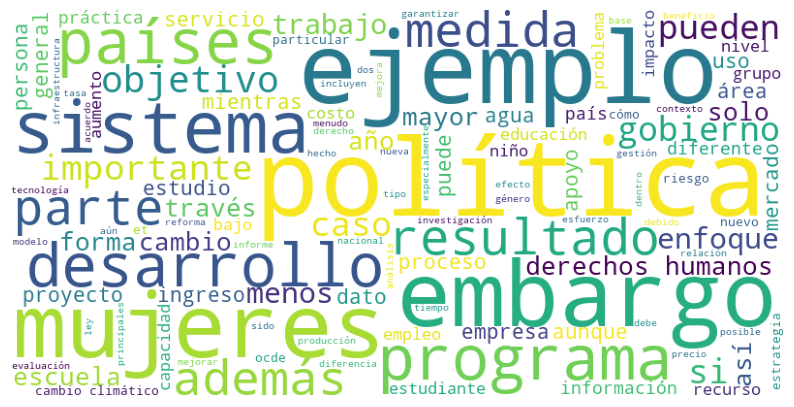

In [123]:
plt.figure(figsize=(10, 10))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [124]:
freq_embargo = data['textos'].str.contains(r'\bembargo\b', regex=True).mean()
print(f'"embargo" aparece en el {freq_embargo:.1%} de los textos')

"embargo" aparece en el 14.7% de los textos


### 3.4.4 Nubes de palabras por ODS

Comparamos el vocabulario dominante entre los 4 ODS con más textos, para verificar si hay diferencias reales de vocabulario entre categorías antes de construir el modelo es la evidencia visual de que el problema de clasificación es viable con este preprocesamiento.

In [125]:
# 3.4.5 Definimos una función para contar las palabras más frecuentes en un subconjunto de textos ya tokenizados

In [126]:
def top_terminos(tokens_subset, n=60):
    todas_las_palabras = [word for tokens in tokens_subset for word in tokens]
    frecuencias = pd.Series(todas_las_palabras).value_counts().head(n)
    return frecuencias

In [127]:
# 3.4.6 Identificamos los 4 ODS con más textos

In [128]:
ods_top4 = data['ODS'].value_counts().nlargest(4).index.tolist()

In [129]:
ods_top4

[16, 5, 4, 3]

In [130]:
# 3.4.8 Generamos una nube de palabras por cada uno de esos ODS

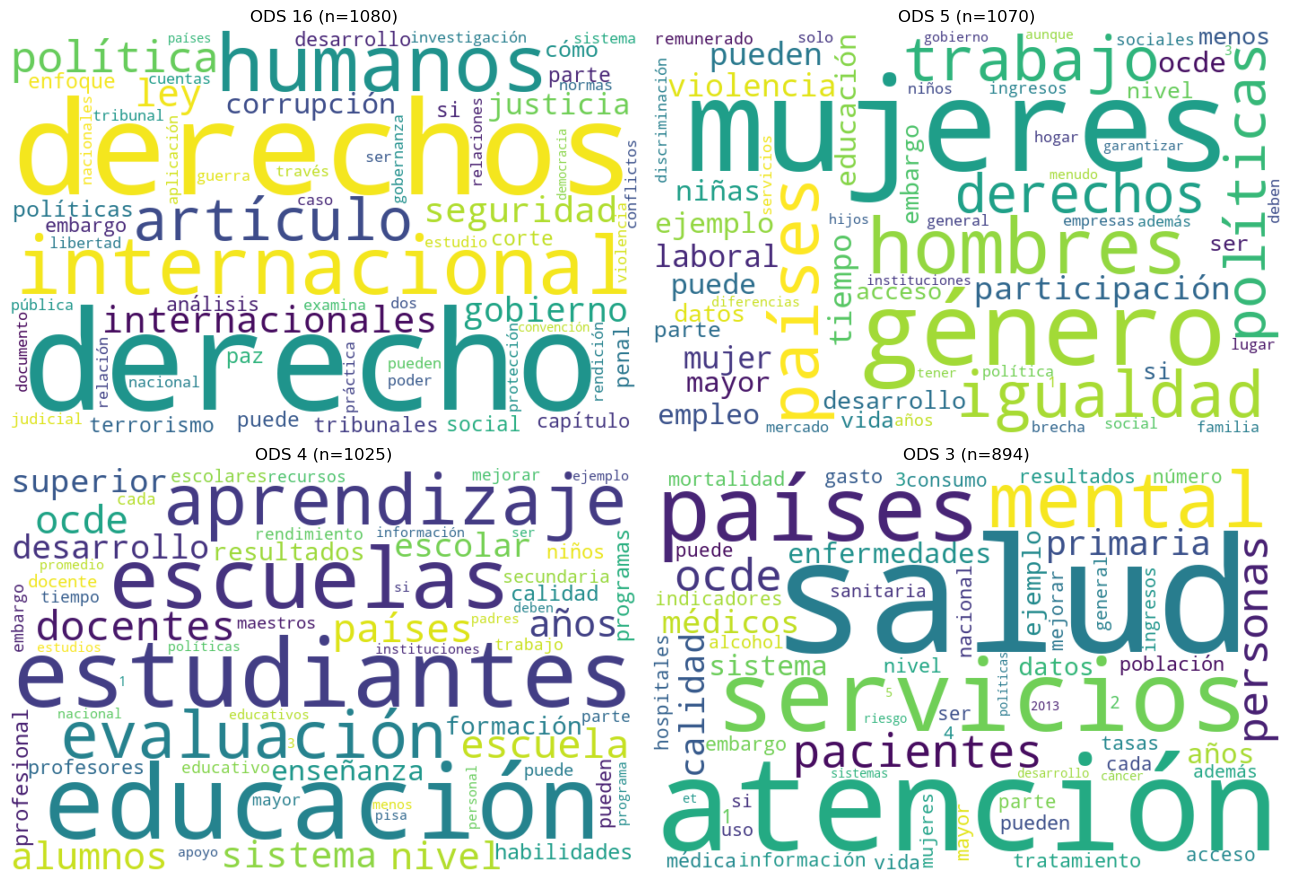

In [131]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, ods in zip(axes.ravel(), ods_top4):
    indices_ods = data.index[data['ODS'] == ods]
    tokens_ods = no_stopwords.loc[indices_ods]
    frecuencias = top_terminos(tokens_ods, n=60)

    nube = WordCloud(width=700, height=450, background_color='white', colormap='viridis').generate_from_frequencies(frecuencias.to_dict())
    ax.imshow(nube, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'ODS {ods} (n={len(tokens_ods)})')

plt.tight_layout()
plt.show()

**Lectura de 3.4.5:** las cuatro nubes muestran vocabulario claramente distinto y coherente con el nombre de cada ODS (derechos/justicia para ODS 16, género/mujeres para ODS 5, educación/estudiantes para ODS 4, salud/atención para ODS 3), sin solapamiento significativo entre categorías. Esto es evidencia temprana de que la representación TF-IDF va a tener señal suficiente para que el clasificador distinga entre ODS. Además, se confirma que "embargo" y "ejemplo" aparecen con presencia similar en las cuatro nubes consistente con nuestra decisión de no filtrarlas manualmente, ya que no aportan a la diferenciación entre clases.

### 3.5 Stemming

Palabras como "pobreza", "pobre" y "empobrecido" están relacionadas con el mismo ODS, pero si el modelo las trata como términos distintos, divide la señal entre varias columnas de la matriz en vez de concentrarla en una sola. El stemming las reduce a una raíz común, para que todas cuenten como evidencia del mismo concepto. Usamos `SnowballStemmer('spanish')`, ya que `PorterStemmer` (del tutorial de referencia) es específico de inglés.

In [132]:
# 3.5.1 Definimos el stemmer en español

In [133]:
stemmer = SnowballStemmer('spanish')

In [134]:
# 3.5.2 Aplicamos stemming a cada texto

In [135]:
stemmed = no_stopwords.apply(lambda x: [stemmer.stem(token) for token in x])

In [136]:
stemmed.iloc[0]

['aprendizaj',
 'educ',
 'consider',
 'sinon',
 'escolariz',
 'formal',
 'organiz',
 'auxiliar',
 'editorial',
 'educ',
 'junt',
 'examin',
 'organiz',
 'formacion',
 'docent',
 'consider',
 'extension',
 'acuerd',
 'establec',
 'gobi',
 'marc',
 'comprension',
 'vuelt',
 'cad',
 'vez',
 'inadecu']

In [137]:
# 3.5.3 Comparamos el vocabulario antes y después del stemming

In [138]:
vocab_stemmed = set(word for tokens in stemmed for word in tokens)

In [139]:
print(f'Vocabulario antes del stemming: {len(vocab_despues)}')

Vocabulario antes del stemming: 34630


In [140]:
print(f'Vocabulario después del stemming: {len(vocab_stemmed)}')

Vocabulario después del stemming: 18416


In [141]:
# 3.5.4 Reconstruimos el texto procesado como string

In [142]:
processed = stemmed.apply(lambda x: ' '.join(x))

**Lectura de 3.5:** el stemming redujo el vocabulario de 34.630 a 18.416 palabras una reducción del 46.8%, casi a la mitad. Es una caída mucho más grande que la de quitar stopwords (solo 184), lo cual tiene sentido: el español es un idioma con mucha flexión (género, número, conjugaciones verbales), así que reducir cada palabra a su raíz consolida muchas variantes ("derecho", "derechos", "derechizar") en una sola entrada del vocabulario, concentrando la señal que el TF-IDF puede aprovechar por concepto en vez de dispersarla entre formas gramaticales.

### 3.6 Representación TF-IDF

Convertimos cada texto en un vector numérico donde cada palabra pesa según qué tan característica es de ese texto frente al resto del corpus. Una palabra que aparece en textos de los 17 ODS por igual (como "desarrollo") pesa poco; una palabra que aparece casi exclusivamente en textos de un ODS específico pesa más es justo esa diferencia de peso la que el clasificador va a aprovechar para decidir a qué ODS pertenece un texto nuevo.

In [143]:
# 3.6.1 Construimos la matriz TF-IDF

In [144]:
tfidf_vectorizer = TfidfVectorizer()

In [145]:
x_tfidf = tfidf_vectorizer.fit_transform(processed)

In [146]:
x_tfidf.shape

(9655, 18379)

In [147]:
# 3.6.2 Calculamos la dispersión (sparsity) de la matriz

In [148]:
sparsity = 1 - (x_tfidf.nnz / (x_tfidf.shape[0] * x_tfidf.shape[1]))
print(f'Dimensiones: {x_tfidf.shape}')
print(f'Dispersión: {sparsity:.4%}')

Dimensiones: (9655, 18379)
Dispersión: 99.7394%


**Lectura de 3.6:** la matriz TF-IDF final tiene dimensiones (9.655, 18.379) y una dispersión de 99.74% es decir, más del 99% de las celdas son ceros, porque cada texto individual solo usa una fracción mínima del vocabulario total del corpus. Nota que 18.379 es un poco menor que los 18.416 términos que contamos manualmente tras el stemming: `TfidfVectorizer` usa su propio patrón de tokenización internamente (que exige al menos 2 caracteres por palabra), así que descarta los stems de una sola letra que nuestro conteo manual sí incluía una diferencia esperable y sin impacto real. Esta dispersión tan alta es justamente la que justifica aplicar SVD truncado en la sección 4: reduce miles de columnas mayormente vacías a una representación densa y manejable para el clasificador.

### 3.7 Función de preprocesamiento reutilizable

Encapsulamos los pasos 3.2 a 3.5 en una función `preprocess_text()` porque el pipeline de clasificación (sección 5) necesita aplicar exactamente el mismo procesamiento a los textos nuevos que se quieran clasificar no podemos pedirle al modelo que prediga el ODS de un texto crudo si fue entrenado con texto ya tokenizado, sin stopwords y con stemming. Esta misma función es la que reutilizaríamos si el texto de entrada viene de un usuario en la app de Streamlit (bono opcional).

In [149]:
# 3.7.1 Definimos la función de preprocesamiento

In [150]:
spanish_stopwords_set = set(stopwords.words('spanish'))

In [151]:
spanish_stemmer = SnowballStemmer('spanish')

In [152]:
def preprocess_text(text):
    tokenizer = RegexpTokenizer(r'\w+')
    tokens = tokenizer.tokenize(text)
    tokens = [word for word in tokens if word not in spanish_stopwords_set]
    tokens = [spanish_stemmer.stem(word) for word in tokens]
    return ' '.join(tokens)

In [153]:
# 3.7.2 Construimos el vectorizador con la función de preprocesamiento integrada

In [154]:
tfidf_vectorizer_final = TfidfVectorizer(preprocessor=preprocess_text)

In [155]:
x_tfidf_final = tfidf_vectorizer_final.fit_transform(data['textos'])

In [156]:
x_tfidf_final.shape

(9655, 18379)

In [157]:
# 3.7.3 Verificamos que el resultado es equivalente al obtenido paso a paso

In [158]:
x_tfidf_final.shape == x_tfidf.shape

True

**Lectura de 3.7:** `x_tfidf_final.shape == x_tfidf.shape` dio `True`, confirmando que `preprocess_text()` reproduce exactamente el mismo procesamiento manual de las secciones 3.2 a 3.5. Esta función queda lista para integrarse como `preprocessor` en el pipeline de clasificación de la sección 4, y para reutilizarse tal cual en el despliegue con Streamlit si se hace el bono.

## 4. Modelado de tópicos con LSA (TruncatedSVD)

Con 18.379 columnas y 99.74% de ceros, la matriz TF-IDF es demasiado dispersa para meterla directo a un clasificador, y no ayuda que el dataset esté traducido con DeepL y aumentado con ChatGPT: es fácil que el mismo ODS aparezca descrito con palabras distintas en textos distintos (p.ej. "agua potable" vs "recurso hídrico"), y para TF-IDF esas son columnas sin ninguna relación entre sí. LSA (TruncatedSVD) comprime esas columnas dispersas en un espacio denso de pocas decenas de dimensiones, agrupando en un mismo componente las palabras que aparecen juntas en los mismos textos aunque no sean literalmente iguales. El enunciado pide explorar entre 10 y 20 componentes e interpretar al menos 5 frente a los 17 ODS, que es lo que hacemos en esta sección.

### 4.1 Exploración del número de componentes

In [159]:
# 4.1.1 Ajustamos un SVD amplio (20 componentes) para explorar cuánta varianza captura cada uno

In [160]:
svd_exploracion = TruncatedSVD(n_components=20, random_state=42)

In [161]:
# 4.1.2 Proyectamos la matriz TF-IDF final al espacio de 20 componentes

In [162]:
x_svd_exploracion = svd_exploracion.fit_transform(x_tfidf_final)

In [163]:
# 4.1.3 Revisamos la varianza explicada por cada componente individual

In [164]:
svd_exploracion.explained_variance_ratio_

array([0.00229433, 0.00755559, 0.00714613, 0.006006  , 0.00550557,
       0.00524776, 0.00483263, 0.00443678, 0.00363332, 0.00353129,
       0.00323035, 0.00308468, 0.00299406, 0.00284395, 0.00262203,
       0.00254585, 0.00249184, 0.00240902, 0.00235022, 0.0022327 ])

In [165]:
# 4.1.4 Calculamos la varianza acumulada a medida que se agregan componente

In [166]:
varianza_acumulada = np.cumsum(svd_exploracion.explained_variance_ratio_)

In [167]:
varianza_acumulada

array([0.00229433, 0.00984992, 0.01699605, 0.02300205, 0.02850761,
       0.03375538, 0.03858801, 0.04302479, 0.04665811, 0.0501894 ,
       0.05341974, 0.05650443, 0.05949848, 0.06234244, 0.06496446,
       0.06751032, 0.07000216, 0.07241118, 0.0747614 , 0.07699411])

In [168]:
# 4.1.5 Visualizamos la varianza individual y acumulada por componente

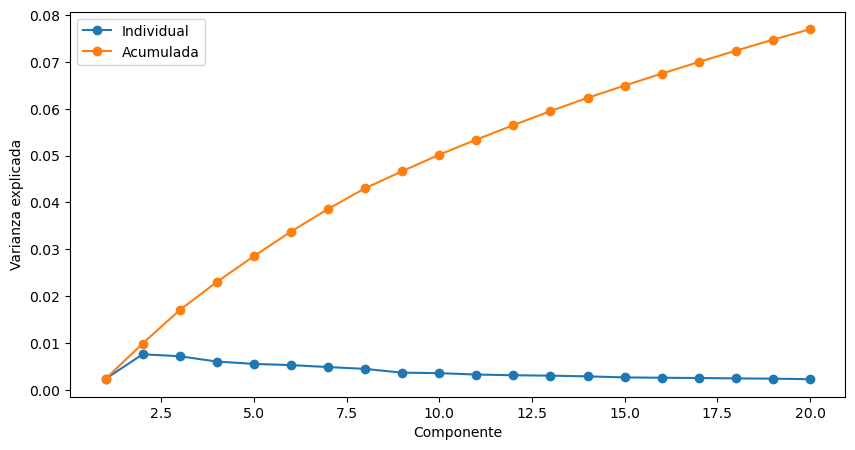

In [169]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, 21), svd_exploracion.explained_variance_ratio_, marker='o', label='Individual')
plt.plot(range(1, 21), varianza_acumulada, marker='o', label='Acumulada')
plt.xlabel('Componente')
plt.ylabel('Varianza explicada')
plt.legend()
plt.show()

## 4.2 Ajuste del modelo final de SVD

In [170]:
# 4.2.1 Ajustamos el SVD final con 15 componentes

In [171]:
svd = TruncatedSVD(n_components=15, random_state=42)

In [172]:
# 4.2.2 Proyectamos la matriz TF-IDF final al espacio de 15 componentes

In [173]:
x_svd = svd.fit_transform(x_tfidf_final)

In [174]:
# 4.2.3 Verificamos la forma resultante

In [175]:
x_svd.shape

(9655, 15)

In [176]:
# 4.2.4 Visualizamos el punto de corte elegido (15) sobre la curva de varianza de 4.1

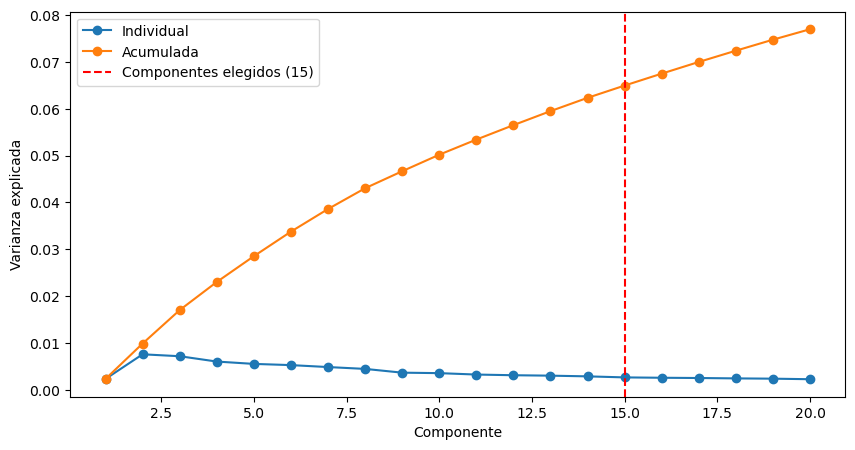

In [177]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, 21), svd_exploracion.explained_variance_ratio_, marker='o', label='Individual')
plt.plot(range(1, 21), varianza_acumulada, marker='o', label='Acumulada')
plt.axvline(x=15, color='red', linestyle='--', label='Componentes elegidos (15)')
plt.xlabel('Componente')
plt.ylabel('Varianza explicada')
plt.legend()
plt.show()

## 4.3 Interpretación cualitativa de los componentes

Cada componente del SVD es una combinación lineal de los términos del vocabulario TF-IDF; svd.components_ guarda, para cada componente, el peso que tiene cada término en esa dirección. Mirando las palabras con mayor peso por componente podemos ver si ese componente agrupa vocabulario de un ODS reconocible como vimos en las nubes de palabras de la sección 3.4, cada ODS grande tiene vocabulario bien distinto, así que si LSA está funcionando deberíamos poder reconocer temas similares acá.

Como el vocabulario final está stemmizado (sección 3.5), las palabras van a salir truncadas (p.ej. "educ" en vez de "educación", "mujer" se queda igual, "agu" en vez de "agua") es esperado, no un error.

In [178]:
# 4.3.1 Obtenemos los términos del vocabulario final

In [179]:
terminos = tfidf_vectorizer_final.get_feature_names_out()

In [180]:
# 4.3.2 Definimos una función que devuelve las palabras con mayor peso en un componente

In [181]:
def top_palabras_componente(componente, terminos, n=12):
    indices_top = componente.argsort()[::-1][:n]
    return [terminos[i] for i in indices_top]

In [182]:
# 4.3.3 Mostramos las palabras más relevantes de cada uno de los 15 componentes

In [183]:
for i, componente in enumerate(svd.components_):
    print(f"Componente {i+1}: {top_palabras_componente(componente, terminos)}")

Componente 1: ['pais', 'polit', 'pued', 'desarroll', 'mujer', 'agu', 'trabaj', 'educ', 'gener', 'mejor', 'derech', 'mayor']
Componente 2: ['agu', 'energ', 'cost', 'energet', 'electr', 'gestion', 'renov', 'climat', 'eficient', 'inversion', 'recurs', 'suministr']
Componente 3: ['derech', 'internacional', 'human', 'agu', 'articul', 'polit', 'tribunal', 'ley', 'penal', 'nacional', 'trat', 'justici']
Componente 4: ['mujer', 'agu', 'gener', 'pobrez', 'hombr', 'derech', 'ingres', 'energ', 'trabaj', 'emple', 'aument', 'econom']
Componente 5: ['agu', 'educ', 'salud', 'escuel', 'calid', 'atencion', 'hidric', 'niñ', 'mujer', 'residual', 'subterran', 'servici']
Componente 6: ['mujer', 'gener', 'hombr', 'iguald', 'agu', 'polit', 'educ', 'particip', 'energ', 'trabaj', 'desarroll', 'empres']
Componente 7: ['salud', 'atencion', 'servici', 'mental', 'medic', 'pacient', 'mujer', 'primari', 'sanitari', 'public', 'segur', 'hospital']
Componente 8: ['energ', 'derech', 'electr', 'educ', 'renov', 'escuel', '

## 4.4 Relación de cada componente con los ODS reales

Promediamos cada componente por ODS y calculamos el margen entre el ODS ganador y el segundo lugar. 8 componentes con margen > 0.05 quedaron interpretados con evidencia sólida: agua (ODS6, x2), salud (ODS3), justicia (ODS16), clima (ODS13), trabajo (ODS8), género (ODS5), energía (ODS7) más del mínimo de 5 que pide el enunciado. 4 componentes (1, 4, 11, 15) resultaron casi sin poder discriminativo (margen < 0.01).

In [184]:
# 4.4.1 Construimos un DataFrame con las coordenadas de cada texto en el espacio LSA

In [185]:
componentes_df = pd.DataFrame(x_svd, columns=[f'comp_{i+1}' for i in range(15)])

In [186]:
componentes_df['ODS'] = data['ODS'].values

In [187]:
# 4.4.2 Calculamos el promedio de cada componente para los textos de cada ODS

In [188]:
promedio_por_ods = componentes_df.groupby('ODS').mean()

In [189]:
promedio_por_ods

,comp_1,comp_2,comp_3,comp_4,comp_5,comp_6,comp_7,comp_8,comp_9,comp_10,comp_11,comp_12,comp_13,comp_14,comp_15
ODS,,,,,,,,,,,,,,,
1,0.168974,-0.028362,-0.090190,0.050865,0.000857,-0.133856,-0.044109,-0.045623,-0.054734,-0.052127,-0.030478,0.066807,-0.015856,-0.011153,0.017304
2,0.153665,0.039198,-0.015469,0.022909,-0.027224,-0.032449,-0.007978,-0.013632,0.023801,-0.010878,0.030735,-0.026789,0.092486,0.023103,0.016032
3,0.153557,0.000575,-0.029597,-0.045886,0.031703,-0.056816,0.132789,0.022395,-0.015277,0.026840,0.000135,-0.019310,0.000868,-0.003012,-0.001252
4,0.167303,-0.033332,-0.036370,-0.141519,0.038408,0.022798,-0.077247,0.044915,-0.008590,-0.001970,-0.003494,-0.000442,0.010926,0.003761,-0.006232
5,0.185979,-0.117974,-0.031609,0.073594,0.012654,0.096704,0.021006,-0.005942,-0.033127,0.011269,0.001476,0.002896,0.009688,-0.001408,-0.002597
6,0.162604,0.148017,0.045640,0.067978,0.153312,0.025299,-0.025495,0.004862,-0.003273,0.004748,-0.009264,-0.000962,-0.016182,0.005766,0.001446
7,0.163881,0.096122,-0.000089,0.032216,-0.120209,0.022859,-0.003594,0.100226,-0.023778,0.007269,-0.023897,0.014270,-0.020712,0.001002,0.001497
8,0.169243,-0.032860,-0.059027,0.020343,-0.005710,-0.007271,-0.006128,0.004616,0.105731,-0.003511,-0.000694,-0.006047,-0.033605,-0.014638,0.031175
9,0.158128,0.037889,0.007384,-0.020790,-0.043808,0.015084,0.010218,-0.015951,0.030853,-0.016081,0.051872,0.034236,-0.011215,-0.007891,-0.011136


In [190]:
# 4.4.3 Para cada componente, identificamos qué ODS tiene el promedio más alto

In [191]:
promedio_por_ods.idxmax()

comp_1      5
comp_2      6
comp_3     16
comp_4      5
comp_5      6
comp_6      5
comp_7      3
comp_8      7
comp_9      8
comp_10    13
comp_11     9
comp_12     1
comp_13     2
comp_14    13
comp_15    14
dtype: int64

In [192]:
# 4.4.4 Traducimos el ODS dominante de cada componente a su nombre completo

In [193]:
promedio_por_ods.idxmax().map(NOMBRES_ODS)

comp_1                          Igualdad de género
comp_2                   Agua limpia y saneamiento
comp_3       Paz, justicia e instituciones sólidas
comp_4                          Igualdad de género
comp_5                   Agua limpia y saneamiento
comp_6                          Igualdad de género
comp_7                           Salud y bienestar
comp_8         Energía asequible y no contaminante
comp_9     Trabajo decente y crecimiento económico
comp_10                        Acción por el clima
comp_11    Industria, innovación e infraestructura
comp_12                          Fin de la pobreza
comp_13                                Hambre cero
comp_14                        Acción por el clima
comp_15                             Vida submarina
dtype: object

In [194]:
# 4.4.5 Calculamos el margen entre el ODS ganador y el segundo lugar, por componente

In [195]:
margen = promedio_por_ods.apply(lambda col: col.nlargest(2).iloc[0] - col.nlargest(2).iloc[1], axis=0)
margen

comp_1     0.003570
comp_2     0.051895
comp_3     0.105379
comp_4     0.005616
comp_5     0.114904
comp_6     0.071405
comp_7     0.111783
comp_8     0.055311
comp_9     0.074879
comp_10    0.081893
comp_11    0.008092
comp_12    0.032572
comp_13    0.025427
comp_14    0.030856
comp_15    0.000320
dtype: float64

In [196]:
# 4.4.6 Construimos una tabla resumen: ODS ganador, nombre y margen de confianza por componente

In [197]:
resumen_componentes = pd.DataFrame({
    'ods_ganador': promedio_por_ods.idxmax(),
    'nombre_ods': promedio_por_ods.idxmax().map(NOMBRES_ODS),
    'margen': margen
})
resumen_componentes.sort_values('margen', ascending=False)

,ods_ganador,nombre_ods,margen
comp_5,6,Agua limpia y saneamiento,0.114904
comp_7,3,Salud y bienestar,0.111783
comp_3,16,"Paz, justicia e instituciones sólidas",0.105379
comp_10,13,Acción por el clima,0.081893
comp_9,8,Trabajo decente y crecimiento económico,0.074879
comp_6,5,Igualdad de género,0.071405
comp_8,7,Energía asequible y no contaminante,0.055311
comp_2,6,Agua limpia y saneamiento,0.051895
comp_12,1,Fin de la pobreza,0.032572
comp_14,13,Acción por el clima,0.030856


**Lectura de 4.4.6:** de los 15 componentes, 8 tienen una interpretación temática clara y verificable frente a los ODS reales, lo que confirma que la representación LSA conserva señal útil para diferenciar ODS y justifica usarla (en vez de la TF-IDF cruda de 18.379 columnas) como entrada del clasificador en la sección 5.

## 4.5 Evaluación cuantitativa de los tópicos (coherencia UMass)

Agregamos esta métrica del curso, que no habíamos usado. Reveló un hallazgo importante: coherencia y margen no siempre coinciden. El componente 1 tiene la mejor coherencia pero el peor margen (es "coherente" solo porque usa vocabulario genérico que aparece en todo el corpus), mientras que el componente 5 (agua/ODS6, nuestro mejor margen) tiene la peor coherencia, porque su vocabulario técnico y específico es justamente lo que lo hace útil pero penaliza a UMass. Solo el componente 15 fue confirmado como débil por ambas métricas.


**Conclusión:** la representación LSA de 15 componentes preserva señal temática real y verificable frente a los ODS, justificando su uso como entrada del clasificador en la siguiente sección.

In [198]:
# 4.5.1 Construimos el diccionario de gensim a partir de los textos ya stemmizados

In [199]:
diccionario_gensim = Dictionary(stemmed.tolist())

In [200]:
# 4.5.4 Obtenemos las palabras top de cada uno de los 15 componentes (usamos los textos de 4.3, ahora como lista de listas)

In [201]:
topicos_palabras = [top_palabras_componente(componente, terminos, n=10) for componente in svd.components_]

In [202]:
# 4.5.5 Calculamos la coherencia UMass para cada tópico

In [203]:
modelo_coherencia = CoherenceModel(topics=topicos_palabras, texts=stemmed.tolist(), dictionary=diccionario_gensim, coherence='u_mass')

In [204]:
coherencia_por_topico = modelo_coherencia.get_coherence_per_topic()

In [205]:
coherencia_por_topico

[np.float64(-1.896858352875654),
 np.float64(-2.092461299687498),
 np.float64(-3.0187771989176597),
 np.float64(-2.4812545840658706),
 np.float64(-5.010751751557098),
 np.float64(-2.241871623487892),
 np.float64(-2.011164904699433),
 np.float64(-3.1089992480936295),
 np.float64(-2.251189525396072),
 np.float64(-2.4531075806424623),
 np.float64(-2.5585707223981604),
 np.float64(-2.648048388945626),
 np.float64(-3.3099587232859813),
 np.float64(-2.4041688497434044),
 np.float64(-4.624028361321125)]

In [206]:
# 4.5.6 Calculamos la coherencia promedio del modelo completo

In [207]:
modelo_coherencia.get_coherence()

np.float64(-2.8074140743411715)

In [208]:
# 4.5.7 Construimos una serie de coherencia por componente, indexada por nombre

In [209]:
coherencia_series = pd.Series(coherencia_por_topico, index=[f'comp_{i+1}' for i in range(15)])

In [210]:
# 4.5.8 Ordenamos de mejor (más cercano a 0) a peor coherencia

In [211]:
coherencia_ordenada = coherencia_series.sort_values(ascending=False)

In [212]:
# 4.5.9 Construimos la tabla comparativa: los 5 mejores y los 5 peores, lado a lado

In [213]:
mejores = coherencia_ordenada.head(5).reset_index()
mejores.columns = ['Mejor coherencia', 'valor']
peores = coherencia_ordenada.tail(5).sort_values(ascending=True).reset_index()
peores.columns = ['Peor coherencia', 'valor']
tabla_coherencia = pd.concat([mejores, peores], axis=1)
tabla_coherencia

,Mejor coherencia,valor,Peor coherencia,valor
0,comp_1,-1.896858,comp_5,-5.010752
1,comp_7,-2.011165,comp_15,-4.624028
2,comp_2,-2.092461,comp_13,-3.309959
3,comp_6,-2.241872,comp_8,-3.108999
4,comp_9,-2.251190,comp_3,-3.018777


## 5. Control de fuga por parafraseo (casi-duplicados)

El dataset se hizo con traducción DeepL y aumentación con ChatGPT, así que es de esperarse que existan textos "familia": el mismo contenido parafraseado varias veces. Si dos textos casi idénticos caen uno en train y otro en test, el modelo no estaría prediciendo sobre algo nuevo sino reconociendo algo que ya vio con otras palabras, y el desempeño reportado quedaría inflado. Por eso este chequeo va antes del `train_test_split`, no en la limpieza de datos de la sección 2.

Empezamos midiendo similitud en el espacio LSA (`x_svd`), buscando para cada texto su vecino más cercano.

In [214]:
# 5.1 Ajustamos el buscador de vecinos sobre el espacio LSA, usando similitud coseno

In [215]:
buscador_vecinos = NearestNeighbors(n_neighbors=2, metric='cosine')

In [216]:
buscador_vecinos.fit(x_svd)

,n_neighbors,2
,radius,1.0
,algorithm,'auto'
,leaf_size,30
,metric,'cosine'
,p,2
,metric_params,None
,n_jobs,None


In [217]:
# 5.2 Para cada texto, encontramos su vecino más cercano

In [218]:
distancias, indices_vecinos = buscador_vecinos.kneighbors(x_svd)

In [219]:
# 5.4 Convertimos distancia coseno a similitud coseno y nos quedamos con el vecino real (columna 1, no la 0 que es el texto mismo)

In [220]:
similitud_vecino_mas_cercano = 1 - distancias[:, 1]

In [221]:
# 5.5 Visualizamos la distribución de similitudes con el vecino más cercano

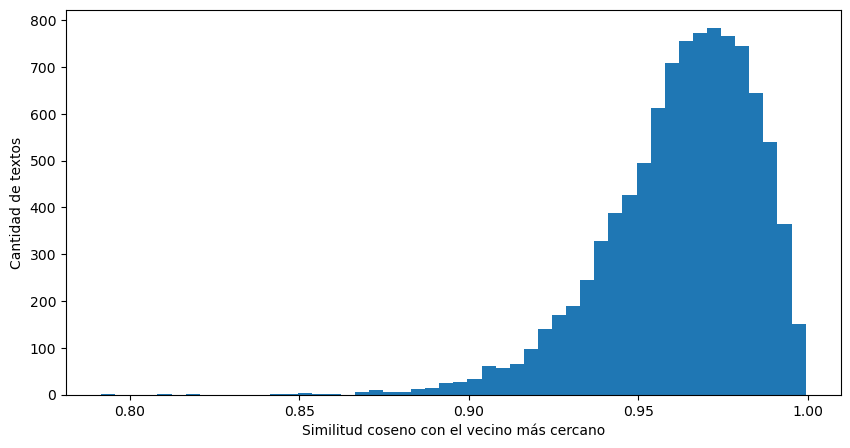

In [222]:
plt.figure(figsize=(10, 5))
plt.hist(similitud_vecino_mas_cercano, bins=50)
plt.xlabel('Similitud coseno con el vecino más cercano')
plt.ylabel('Cantidad de textos')
plt.show()

In [223]:
# 5.6 Revisamos estadísticas descriptivas de la similitud para tener números concretos, no solo la forma del histograma

In [224]:
pd.Series(similitud_vecino_mas_cercano).describe()

count    9655.000000
mean        0.962401
std         0.021919
min         0.791566
25%         0.950324
50%         0.965719
75%         0.978701
max         0.999295
dtype: float64

In [225]:
# 5.7 Guardamos el vecino más cercano de cada texto en el DataFrame, para poder inspeccionar pares completos

In [226]:
data['vecino_mas_cercano'] = indices_vecinos[:, 1]

In [227]:
data['similitud_vecino'] = similitud_vecino_mas_cercano

In [228]:
# 5.8 Inspeccionamos los 5 pares con similitud más alta: ¿son parafraseo real o coincidencia temática?

In [229]:
top_similares = data.sort_values('similitud_vecino', ascending=False).head(5)
for idx in top_similares.index:
    vecino_idx = data.loc[idx, 'vecino_mas_cercano']
    print(f"--- Similitud: {data.loc[idx, 'similitud_vecino']:.4f} | ODS texto: {data.loc[idx, 'ODS']} | ODS vecino: {data.loc[vecino_idx, 'ODS']} ---")
    print(f"TEXTO: {data.loc[idx, 'textos'][:300]}")
    print(f"VECINO: {data.loc[vecino_idx, 'textos'][:300]}")
    print()

--- Similitud: 0.9993 | ODS texto: 16 | ODS vecino: 16 ---
TEXTO: la base convencional de la mayoría de los derechos humanos internacionales, combinada con el dualismo de los sistemas jurídicos del common law, hace que a menudo se considere a los derechos humanos internacionales como uno de los reductos más arraigados del modelo tradicional. en muchas jurisdiccion
VECINO: este capítulo determinará y evaluará el papel del principio general que prohíbe el abuso de derecho en la observancia de los derechos humanos en las relaciones contractuales, esencialmente desde el punto de vista del derecho belga. mientras que este principio ha sido creado y desarrollado en las rel

--- Similitud: 0.9993 | ODS texto: 16 | ODS vecino: 16 ---
TEXTO: este capítulo determinará y evaluará el papel del principio general que prohíbe el abuso de derecho en la observancia de los derechos humanos en las relaciones contractuales, esencialmente desde el punto de vista del derecho belga. mientras que este princip

### Por qué cambiamos de LSA a TF-IDF

Revisando los textos reales detrás de las similitudes más altas en LSA, dos de los tres pares no eran parafraseo: eran párrafos distintos sobre el mismo tema legal (derechos humanos), no el mismo contenido reescrito. LSA con 15 componentes comprime tanto que junta cualquier texto del mismo tema general, que es justo lo que necesitábamos para la sección 4 pero es un problema acá: para detectar duplicados hace falta el detalle fino que LSA descarta a propósito — coincidencia de frases y palabras concretas. Repetimos la búsqueda sobre la matriz TF-IDF completa, que sí conserva ese detalle.

In [230]:
# 5.9 Repetimos la búsqueda de vecino más cercano, esta vez sobre la matriz TF-IDF completa (no el espacio LSA)

In [231]:
buscador_vecinos_tfidf = NearestNeighbors(n_neighbors=2, metric='cosine')
buscador_vecinos_tfidf.fit(x_tfidf_final)

,n_neighbors,2
,radius,1.0
,algorithm,'auto'
,leaf_size,30
,metric,'cosine'
,p,2
,metric_params,None
,n_jobs,None


In [232]:
# 5.10 Buscamos el vecino más cercano de cada texto en el espacio TF-IDF

In [233]:
distancias_tfidf, indices_vecinos_tfidf = buscador_vecinos_tfidf.kneighbors(x_tfidf_final)

In [234]:
# 5.11 Calculamos la similitud coseno con el vecino más cercano (excluyendo el texto mismo)

In [235]:
similitud_vecino_tfidf = 1 - distancias_tfidf[:, 1]

In [236]:
# 5.12 Visualizamos la distribución de similitudes en el espacio TF-IDF

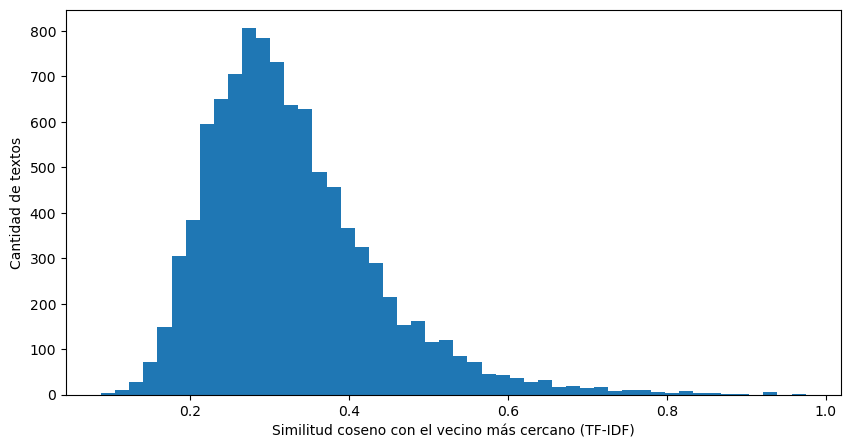

In [237]:
plt.figure(figsize=(10, 5))
plt.hist(similitud_vecino_tfidf, bins=50)
plt.xlabel('Similitud coseno con el vecino más cercano (TF-IDF)')
plt.ylabel('Cantidad de textos')
plt.show()

In [238]:
# 5.13 Revisamos estadísticas descriptivas de la similitud en TF-IDF

In [239]:
pd.Series(similitud_vecino_tfidf).describe()

count    9655.000000
mean        0.328392
std         0.108558
min         0.088072
25%         0.253414
50%         0.308469
75%         0.381587
max         0.974850
dtype: float64

In [240]:
# 5.14 Contamos cuántos textos superan distintos umbrales candidatos

In [241]:
for umbral in [0.5, 0.6, 0.7, 0.8, 0.9]:
    print(f"Similitud > {umbral}: {(similitud_vecino_tfidf > umbral).sum()} textos")

Similitud > 0.5: 692 textos
Similitud > 0.6: 235 textos
Similitud > 0.7: 87 textos
Similitud > 0.8: 31 textos
Similitud > 0.9: 9 textos


In [242]:
# 5.15 Guardamos el vecino más cercano (TF-IDF) en el DataFrame, reemplazando la versión LSA

In [243]:
data['vecino_mas_cercano'] = indices_vecinos_tfidf[:, 1]
data['similitud_vecino'] = similitud_vecino_tfidf

In [244]:
# 5.16 Inspeccionamos los 5 pares con mayor similitud TF-IDF: ¿ahora sí son parafraseo real?

In [245]:
top_similares_tfidf = data.sort_values('similitud_vecino', ascending=False).head(5)

In [246]:
for idx in top_similares_tfidf.index:
    vecino_idx = data.loc[idx, 'vecino_mas_cercano']
    print(f"--- Similitud: {data.loc[idx, 'similitud_vecino']:.4f} | ODS texto: {data.loc[idx, 'ODS']} | ODS vecino: {data.loc[vecino_idx, 'ODS']} ---")
    print(f"TEXTO: {data.loc[idx, 'textos'][:300]}")
    print(f"VECINO: {data.loc[vecino_idx, 'textos'][:300]}")
    print()

--- Similitud: 0.9748 | ODS texto: 14 | ODS vecino: 14 ---
TEXTO: las cifras de transferencias al sector que se informan aquí incluyen estimaciones de los gastos de gestión y cumplimiento, cuando faltan. los valores totales mundiales de producción para pesca y acuicultura se obtuvieron del anuario de la fao, estadísticas de pesca y acuicultura, 2015. ambos números
VECINO: los números de 'transferencias al sector' informados aquí incluyen estimaciones de gastos de administración y cumplimiento, donde faltan. los valores totales de producción mundial para pesca y acuicultura se obtuvieron del anuario de la fao, estadísticas de pesca y acuicultura, 2015. ambos números s

--- Similitud: 0.9748 | ODS texto: 14 | ODS vecino: 14 ---
TEXTO: los números de 'transferencias al sector' informados aquí incluyen estimaciones de gastos de administración y cumplimiento, donde faltan. los valores totales de producción mundial para pesca y acuicultura se obtuvieron del anuario de la fao, estadísticas de

In [247]:
# 5.17 Inspeccionamos una muestra de pares en la zona intermedia (0.65-0.75) para decidir si el umbral debe estar ahí o más alto

In [248]:
zona_intermedia = data[(data['similitud_vecino'] >= 0.65) & (data['similitud_vecino'] <= 0.75)].head(5)
for idx in zona_intermedia.index:
    vecino_idx = data.loc[idx, 'vecino_mas_cercano']
    print(f"--- Similitud: {data.loc[idx, 'similitud_vecino']:.4f} | ODS texto: {data.loc[idx, 'ODS']} | ODS vecino: {data.loc[vecino_idx, 'ODS']} ---")
    print(f"TEXTO: {data.loc[idx, 'textos'][:300]}")
    print(f"VECINO: {data.loc[vecino_idx, 'textos'][:300]}")
    print()

--- Similitud: 0.7342 | ODS texto: 15 | ODS vecino: 15 ---
TEXTO: el requisito de compensación puede ajustar el tamaño o el alcance de una compensación de biodiversidad en relación con la biodiversidad medida en un lugar de compensación, para tener en cuenta el riesgo de que no se realice una compensación, los desfases temporales y otras diferencias de composición
VECINO: el requisito de compensación es una importante herramienta que permite ajustar el tamaño o alcance de la compensación de biodiversidad, dando cuenta de los riesgos de que una determinada compensación no se lleve a cabo. también considera los desfases temporales y diferencias de composición entre la 

--- Similitud: 0.7107 | ODS texto: 15 | ODS vecino: 15 ---
TEXTO: sin embargo, en un reciente estudio regional sobre el estado de la herpetofauna, el 30,8% de las 13 especies de anfibios y el 13,9% de las 101 especies de reptiles de marruecos se consideraron amenazadas, mientras que dos especies se consideraron extinguida

In [249]:
# 5.18 Inspeccionamos una muestra más abajo (0.5-0.6) para ver si ahí todavía es parafraseo o ya es solo coincidencia temática

In [250]:
zona_baja = data[(data['similitud_vecino'] >= 0.5) & (data['similitud_vecino'] <= 0.6)].sample(5, random_state=42)
for idx in zona_baja.index:
    vecino_idx = data.loc[idx, 'vecino_mas_cercano']
    print(f"--- Similitud: {data.loc[idx, 'similitud_vecino']:.4f} | ODS texto: {data.loc[idx, 'ODS']} | ODS vecino: {data.loc[vecino_idx, 'ODS']} ---")
    print(f"TEXTO: {data.loc[idx, 'textos'][:300]}")
    print(f"VECINO: {data.loc[vecino_idx, 'textos'][:300]}")
    print()

--- Similitud: 0.5153 | ODS texto: 6 | ODS vecino: 6 ---
TEXTO: como resultado, los vertidos de las edar a los cuerpos de agua están contaminados por sustancias orgánicas, amonio y nitratos. otro motivo del tratamiento deficiente de las aguas residuales es la gran capacidad de las plantas de tratamiento de aguas residuales en relación con las aguas residuales en
VECINO: el informe de la ocde de 2009, relativo a la calidad del agua y las aguas residuales, explica por qué grecia ha experimentado graves retrasos en la aplicación de la directiva de la ue sobre aguas residuales urbanas y en la gestión de las aguas residuales. el informe recomienda encarecidamente la mej

--- Similitud: 0.5394 | ODS texto: 4 | ODS vecino: 4 ---
TEXTO: los estudiantes nacidos en el extranjero que regresan son estudiantes nacidos en el extranjero de uno o más padres nacidos en suecia. entre los estudiantes inmigrantes de primera generación, los hablantes no nativos tenían 13 puntos porcentuales menos de probab

In [251]:
# 5.19 Fijamos el umbral final de casi-duplicado en 0.65 y contamos cuántos textos lo superan

In [252]:
umbral_duplicado = 0.65
(data['similitud_vecino'] > umbral_duplicado).sum()

np.int64(136)

In [253]:
# 5.20 Construimos un grafo: cada texto conectado con su vecino más cercano, solo si supera el umbral

In [254]:
n = len(data)

In [255]:
filas = data.index[data['similitud_vecino'] > umbral_duplicado]

In [256]:
columnas = data.loc[filas, 'vecino_mas_cercano']

In [257]:
grafo = csr_matrix((np.ones(len(filas)), (filas, columnas)), shape=(n, n))

In [258]:
# 5.21 Identificamos las "familias" de parafraseo: grupos de textos conectados transitivamente (A~B~C aunque A y C no sean vecinos directos)

In [259]:
n_familias, etiquetas_familia = connected_components(grafo, directed=False)
data['familia_parafraseo'] = etiquetas_familia

In [260]:
# 5.22 Revisamos cuántas familias tienen más de un texto (las que realmente importan para el split)

In [261]:
tamanos_familia = data['familia_parafraseo'].value_counts()

In [262]:
familias_multiples = tamanos_familia[tamanos_familia > 1]

In [263]:
print(f"Familias con más de un texto: {len(familias_multiples)}")
print(f"Total de textos afectados: {familias_multiples.sum()}")

Familias con más de un texto: 66
Total de textos afectados: 136


In [264]:
familias_multiples.describe()

count    66.000000
mean      2.060606
std       0.387449
min       2.000000
25%       2.000000
50%       2.000000
75%       2.000000
max       5.000000
Name: count, dtype: float64

**Lectura de la sección 5:** con TF-IDF la distribución de similitudes cambió por completo la mayoría de textos entre 0.25 y 0.35 con su vecino más cercano, y una cola larga y separada hacia 1.0. Para fijar el umbral no nos quedamos con la forma del histograma: revisamos texto real en tres franjas. En 0.65-0.75 los 5 pares revisados compartían cifras y hechos idénticos (75.530 hectáreas, "65 vertederos", "marzo de 2009") con solo la redacción cambiada parafraseo real. En 0.5-0.6 la cosa cambió: 4 de 5 pares compartían tema pero con datos distintos (13% vs 17%, informes y resoluciones distintas) ya no es la misma información, es coincidencia temática. El umbral quedó en **0.65**, justo donde termina la zona sin falsos positivos.

Con ese corte, agrupamos los textos conectados (directa o transitivamente) en familias de parafraseo: 66 familias con más de un texto, 136 textos en total (1.4% del dataset), la mayoría pares y una familia de 5. Esa columna (`familia_parafraseo`) es la que usamos en la partición train/test para que ninguna familia quede repartida entre los dos conjuntos.

## 6. Partición de los datos (train/test)

`train_test_split` estratifica por ODS pero no respeta grupos, y `GroupShuffleSplit` respeta grupos pero no estratifica necesitamos las dos cosas a la vez, porque las clases ya están desbalanceadas (312 a 1.080 textos según el ODS) y además no podemos partir ninguna familia de parafraseo. `StratifiedGroupKFold` hace ambas: lo usamos con 5 particiones (≈80/20) y tomamos solo la primera en vez de correr las 5, porque acá no estamos haciendo validación cruzada, solo necesitamos un split.

In [265]:
# 6.1 Configuramos 5 particiones (equivale a un split aproximado 80/20) y tomamos la primera

In [266]:
skf_grupos = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

In [267]:
indices_train, indices_test = next(skf_grupos.split(data, data['ODS'], groups=data['familia_parafraseo']))

In [268]:
# 6.2 Construimos los conjuntos de entrenamiento y prueba a partir de los índices

In [269]:
train_data = data.iloc[indices_train]

In [270]:
test_data = data.iloc[indices_test]

In [271]:
train_data.shape, test_data.shape

((7720, 8), (1935, 8))

In [272]:
# 6.3 Verificamos que ninguna familia con más de un texto quedó partida entre train y test

In [273]:
familias_train = set(train_data['familia_parafraseo'])

In [274]:
familias_test = set(test_data['familia_parafraseo'])

In [275]:
len(familias_train & familias_test)

0

In [276]:
# Nota: la partición quedó limpia, sin fuga por parafraseo.

In [277]:
# 6.4 Comparamos la proporción de cada ODS en train vs test

In [278]:
proporciones = pd.DataFrame({
    'train': train_data['ODS'].value_counts(normalize=True),
    'test': test_data['ODS'].value_counts(normalize=True)
})

In [279]:
proporciones['diferencia'] = (proporciones['train'] - proporciones['test']).abs()

In [280]:
proporciones.sort_values('diferencia', ascending=False)

,train,test,diferencia
ODS,,,
12,0.030311,0.040310,0.009999
8,0.047539,0.040827,0.006712
7,0.080181,0.086822,0.006640
4,0.107383,0.101292,0.006091
3,0.091580,0.096641,0.005061
16,0.112824,0.108010,0.004813
5,0.111788,0.106977,0.004811
15,0.035104,0.030491,0.004613
1,0.053109,0.049096,0.004013


**Lectura de la sección 6:** el split quedó en 7.720 textos de entrenamiento y 1.935 de prueba (79.9%/20.1%), sin ninguna familia de parafraseo compartida entre los dos conjuntos y con las proporciones por ODS prácticamente iguales en ambos (diferencia máxima de 1 punto porcentual, en la clase más pequeña). Con esto la partición está lista para construir el pipeline de clasificación sin riesgo de fuga de información.

## 7. Pipeline y modelo de clasificación

El objetivo es separar bien los componentes de LSA, tambien es clasificar textos de política pública en el ODS correcto para que alguien pueda tomar decisiones con eso así que necesitamos un modelo que generalice a textos que nunca vio, no uno que memorice el corpus de entrenamiento. Por eso comparamos dos algoritmos en vez de asumir uno: `LogisticRegression`, que asume fronteras relativamente simples entre ODS, y `RandomForestClassifier`, que puede captar relaciones más enredadas entre los componentes de LSA si las hay. No sabemos de antemano cuál le queda mejor a este problema, así que dejamos que el `GridSearchCV` lo decida con evidencia en vez de intuición.

Las clases siguen desbalanceadas (algunos ODS tienen muchos más textos que otros, como vimos en 2.3), así que ambos modelos usan `class_weight='balanced'` para no ignorar los ODS chicos, y medimos con F1 macro en vez de accuracy por la misma razón: un modelo que solo acierta en los ODS grandes no nos sirve para el objetivo real del proyecto.

In [281]:
# 7.1 Construimos el pipeline: preprocesamiento + TF-IDF + SVD + clasificador

In [282]:
pipeline_clasificacion = Pipeline(steps=[
    ('tfidf', TfidfVectorizer(preprocessor=preprocess_text)),
    ('svd', TruncatedSVD(n_components=15, random_state=42)),
    ('clasificador', LogisticRegression())
])

In [283]:
# 7.2 Definimos la grilla de búsqueda: dos configuraciones de algoritmo distintas dentro del mismo GridSearchCV

In [284]:
param_grid = [
    {
        'svd__n_components': [150, 300, 500, 1000],
        'clasificador': [LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)],
        'clasificador__C': [0.1, 1, 10]
    },
    {
        'svd__n_components': [150, 300, 500, 1000],
        'clasificador': [RandomForestClassifier(n_estimators=200, max_depth=20, class_weight='balanced', random_state=42)]
    },
    {
        'svd__n_components': [150, 300, 500, 1000],
        'clasificador': [LinearSVC(class_weight='balanced', random_state=42, max_iter=5000)],
        'clasificador__C': [0.1, 1, 10]
    }
]

In [285]:
# 7.3 Configuramos la búsqueda de hiperparámetros con validación cruzada de 5 folds, optimizando F1 macro

In [286]:
busqueda = GridSearchCV(pipeline_clasificacion, param_grid, cv=5, scoring='f1_macro', n_jobs=-1, verbose=2)

In [287]:
# 7.4 Ajustamos la búsqueda sobre los datos de entrenamiento

In [288]:
busqueda.fit(train_data['textos'], train_data['ODS'])

Fitting 5 folds for each of 28 candidates, totalling 140 fits


,estimator,Pipeline(step...egression())])
,param_grid,"[{'clasificador': [LogisticRegre...ndom_state=42)], 'clasificador__C': [0.1, 1, ...], 'svd__n_components': [150, 300, ...]}, {'clasificador': [RandomForestC...ndom_state=42)], 'svd__n_components': [150, 300, ...]}, ...]"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,input,'content'


In [289]:
# 7.6 Revisamos cuál fue la mejor combinación de algoritmo e hiperparámetros

In [290]:
busqueda.best_params_

{'clasificador': LinearSVC(class_weight='balanced', max_iter=5000, random_state=42),
 'clasificador__C': 1,
 'svd__n_components': 1000}

In [291]:
# 7.7 Revisamos el F1 macro promedio (validación cruzada) de esa mejor combinación

In [292]:
busqueda.best_score_

np.float64(0.8614582129203161)

In [293]:
# 7.8 Guardamos el mejor pipeline ya ajustado, para usarlo en la evaluación

In [294]:
mejor_pipeline = busqueda.best_estimator_

In [295]:
# 7.9 Generamos las predicciones del mejor pipeline sobre los datos de prueba

In [296]:
predicciones_test = mejor_pipeline.predict(test_data['textos'])

In [297]:
# 7.10 Revisamos el reporte de clasificación completo (precisión, recall, F1 por cada ODS)

In [298]:
print(classification_report(test_data['ODS'], predicciones_test))

              precision    recall  f1-score   support

           1       0.85      0.81      0.83        95
           2       0.76      0.87      0.81        76
           3       0.92      0.94      0.93       187
           4       0.94      0.95      0.94       196
           5       0.90      0.92      0.91       207
           6       0.92      0.92      0.92       140
           7       0.91      0.90      0.90       168
           8       0.69      0.66      0.68        79
           9       0.79      0.77      0.78        64
          10       0.73      0.64      0.68        72
          11       0.92      0.87      0.89       126
          12       0.92      0.86      0.89        78
          13       0.84      0.93      0.88        99
          14       0.90      0.94      0.92        80
          15       0.98      0.93      0.96        59
          16       0.96      0.96      0.96       209

    accuracy                           0.89      1935
   macro avg       0.87   

In [299]:
# 7.11 Visualizamos la matriz de confusión para ver con qué ODS se confunde el modelo

In [300]:
matriz_confusion_norm = confusion_matrix(test_data['ODS'], predicciones_test, normalize='true')

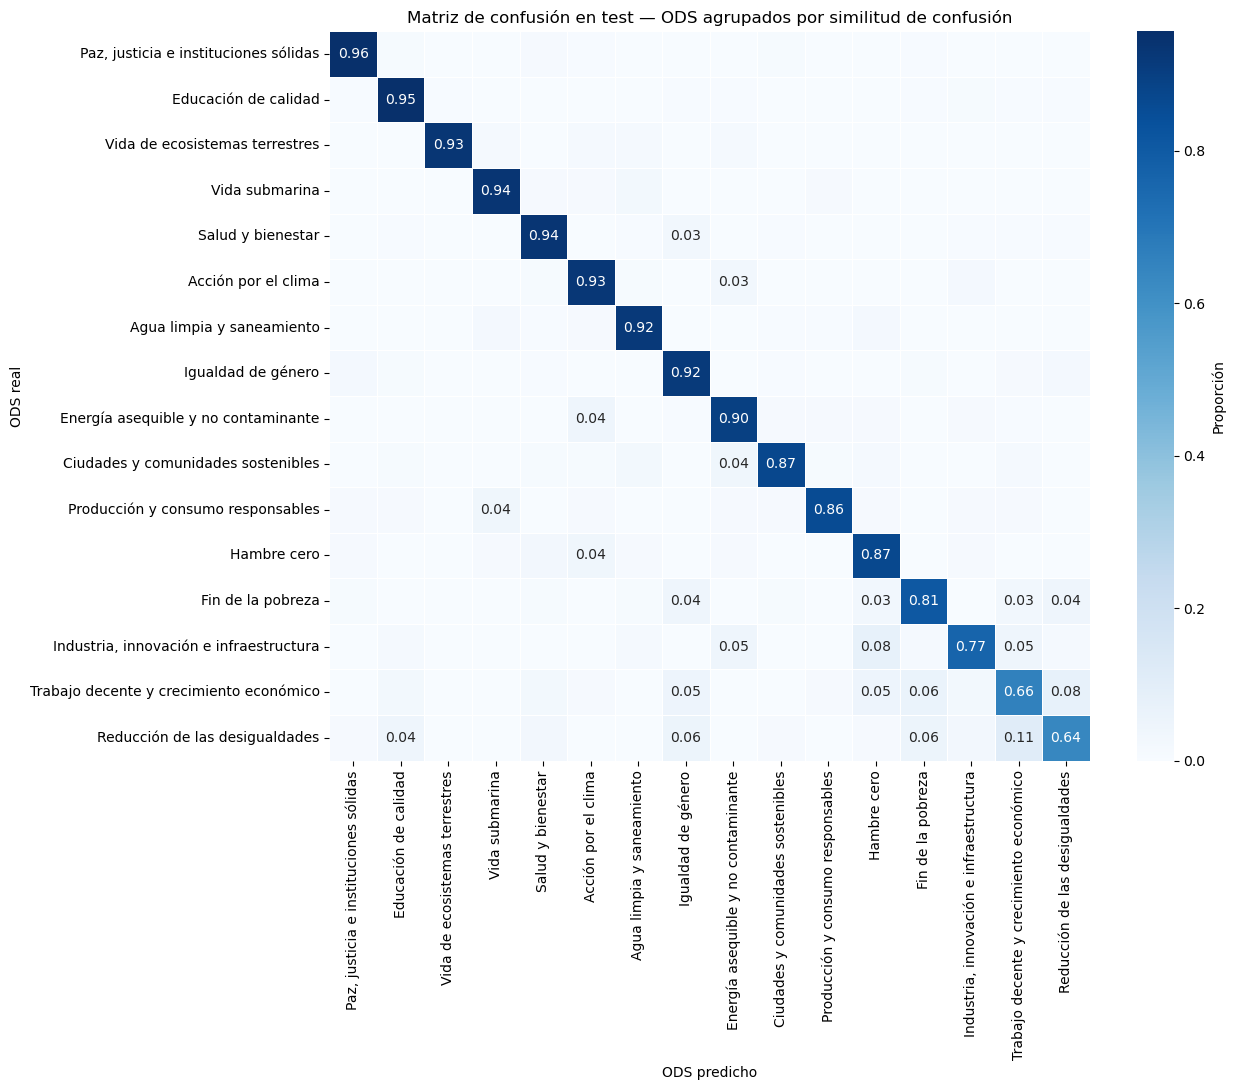

In [301]:
orden = leaves_list(linkage(matriz_confusion_norm, method='average'))
matriz_reordenada = matriz_confusion_norm[orden][:, orden]
ods_ordenados = np.array(sorted(test_data['ODS'].unique()))[orden]
etiquetas_ordenadas = [NOMBRES_ODS[i] for i in ods_ordenados]

anotaciones = np.where(matriz_reordenada >= 0.03,
                        np.vectorize(lambda x: f'{x:.2f}')(matriz_reordenada), '')

plt.figure(figsize=(13, 11))
sns.heatmap(matriz_reordenada, annot=anotaciones, fmt='', cmap='Blues',
            xticklabels=etiquetas_ordenadas, yticklabels=etiquetas_ordenadas,
            linewidths=0.5, linecolor='white', cbar_kws={'label': 'Proporción'})
plt.xlabel('ODS predicho')
plt.ylabel('ODS real')
plt.title('Matriz de confusión en test — ODS agrupados por similitud de confusión')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Lectura de la matriz de confusión:** al reordenar los ODS por parecido en sus errores, la diagonal va perdiendo fuerza hacia abajo hasta un bloque final de cuatro: Fin de la pobreza, Industria, Trabajo y Reducción de las desigualdades, con valores de 0.64 a 0.81. Son los únicos cuatro que se confunden entre sí por encima de 0.05 el resto del mapa apenas llega a 0.03-0.04 fuera de la diagonal.

El clustering los agrupó solo por sus errores, sin que nosotros interviniéramos, y coincide exactamente con los cuatro ODS que ya tenían el F1 más bajo en el `classification_report`. Esa zona económica (pobreza, industria, trabajo, desigualdad) es la debilidad real del modelo; el resto de los ODS se distingue bien.

## 8. Evidencia del desempeño con textos no vistos

Ya evaluamos el modelo sobre todo el conjunto de test, pero la rúbrica pide algo más puntual: mostrar de forma explícita cómo se comporta el modelo frente a textos individuales que nunca vio en el entrenamiento. Tomamos una muestra aleatoria de 4 textos del test y comparamos, uno por uno, el ODS real contra el que predijo `mejor_pipeline`, para verificar de forma directa que la clasificación

In [302]:
# 8.1 Tomamos una muestra de 4 textos del conjunto de test

In [303]:
muestra_test = test_data.sample(4, random_state=42)

In [304]:
# 8.2 Generamos las predicciones del modelo sobre esa muestra

In [305]:
predicciones_muestra = mejor_pipeline.predict(muestra_test['textos'])

In [306]:
# 8.3 Comparamos texto, ODS real y ODS predicho

In [307]:
for texto, real, pred in zip(muestra_test['textos'], muestra_test['ODS'], predicciones_muestra):
    print(f"Texto: {texto[:200]}...")
    print(f"ODS real: {real} - {NOMBRES_ODS[real]}")
    print(f"ODS predicho: {pred} - {NOMBRES_ODS[pred]}")
    print(f"¿Correcto?: {'Sí' if real == pred else 'No'}")
    print("-" * 80)

Texto: para el distrito de berea, el investigador distribuyó algunas copias de un cuestionario a algunas escuelas, mientras que una cierta parte de las copias del cuestionario fue completada por maestros de ...
ODS real: 4 - Educación de calidad
ODS predicho: 4 - Educación de calidad
¿Correcto?: Sí
--------------------------------------------------------------------------------
Texto: también promueve mejoras en la prevención, el diagnóstico, el tratamiento y la rehabilitación de enfermedades específicas. la construcción y renovación representan alrededor del 30% del presupuesto to...
ODS real: 3 - Salud y bienestar
ODS predicho: 8 - Trabajo decente y crecimiento económico
¿Correcto?: No
--------------------------------------------------------------------------------
Texto: ¿cómo (si acaso) se puede equilibrar el derecho a la libertad de un niño en virtud del artículo 5 del convenio europeo de derechos humanos ('cedh') con los derechos de los padres, consagrados tanto en...
ODS real: 1

**Lectura de la sección 8:**

De los 4 textos de la muestra, el modelo acertó en 2. Acertó en los dos casos más "temáticamente puros": un texto sobre cuestionarios en escuelas (ODS 4, Educación) y otro sobre el artículo 5 del CEDH y los derechos de los padres (ODS 16, Paz y justicia), ambos con vocabulario bastante específico de su ODS.

Los dos errores son coherentes con lo que ya habíamos visto en la matriz de confusión. El texto de salud terminó clasificado como Trabajo decente porque habla de presupuesto para construcción y renovación de infraestructura hospitalaria, un vocabulario que se solapa más con temas económicos que con salud en sí. El otro error, un texto sobre generación de empleo y elecciones tecnológicas que el modelo predijo como Hambre cero en vez de Trabajo decente, confirma que el ODS 8 sigue siendo el más difícil de acertar del conjunto: es el que tiene menor recall en la matriz de confusión y el que más se confunde con otros ODS del bloque económico y social.

Con una muestra de 4 textos no se puede sacar una conclusión estadística, pero sí sirve para ver en la práctica algo que las métricas agregadas ya anticipaban: el modelo funciona bien cuando el texto tiene vocabulario propio de su ODS, y falla cuando el contenido cruza hacia temas económicos o sociales compartidos entre varios ODS.

### 8.4 Textos externos, fuera del dataset

Los 4 textos anteriores acertaron o fallaron, pero siguen siendo del mismo test set, es decir, del mismo corpus de informes traducidos con el que se entrenó el modelo. Para probar algo más exigente escribimos 4 textos nuevos, redactados por fuera del dataset y con un registro distinto al de los informes traducidos, simulando cómo llegaría un texto real si alguien usara este modelo en producción. Además de la predicción principal, mostramos el top-3 con el margen de `decision_function` de `LinearSVC`, aclarando que ese valor no es una probabilidad, solo indica qué tan separada está la primera opción de la segunda.

In [308]:
# 8.4 Definimos 4 textos escritos por fuera del dataset, cada uno pensado para un ODS distinto

In [309]:
textos_externos = [
    "Una cooperativa de energía en un municipio rural instaló paneles solares en las viviendas que no tenían acceso a la red eléctrica, y ahora las familias pueden usar electrodomésticos y estudiar de noche con luz eléctrica.",
    "La empresa publicó su primer informe de brecha salarial y se comprometió a igualar el sueldo entre hombres y mujeres en el mismo cargo, además de extender la licencia de paternidad a cuatro semanas.",
    "La alcaldía inauguró una red de ciclorrutas que conecta los barrios periféricos con el centro de la ciudad, buscando reducir la congestión vehicular y bajar los niveles de contaminación del aire.",
    "El acueducto veredal terminó la construcción de un nuevo tanque de almacenamiento que garantiza agua potable todos los días de la semana a las familias de la zona, que antes solo tenían servicio dos días."
]

In [310]:
# 8.5 Generamos la predicción principal para cada texto externo

In [311]:
predicciones_externas = mejor_pipeline.predict(textos_externos)

In [312]:
clases = mejor_pipeline.classes_

In [313]:
# 8.6 Generamos el margen de decision_function para ver el top-3 de candidatos por texto

In [314]:
margenes = mejor_pipeline.decision_function(textos_externos)
clases = mejor_pipeline.classes_

In [315]:
# 8.7 Mostramos texto, predicción principal y top-3 candidatos con su margen

In [316]:
for texto, pred, margen in zip(textos_externos, predicciones_externas, margenes):
    top3_idx = np.argsort(margen)[::-1][:3]
    print(f"Texto: {texto}")
    print(f"ODS predicho: {pred} - {NOMBRES_ODS[pred]}")
    print("Top-3 candidatos:")
    for idx in top3_idx:
        print(f"  ODS {clases[idx]} - {NOMBRES_ODS[clases[idx]]}: margen {margen[idx]:.3f}")
    print("-" * 80)

Texto: Una cooperativa de energía en un municipio rural instaló paneles solares en las viviendas que no tenían acceso a la red eléctrica, y ahora las familias pueden usar electrodomésticos y estudiar de noche con luz eléctrica.
ODS predicho: 7 - Energía asequible y no contaminante
Top-3 candidatos:
  ODS 7 - Energía asequible y no contaminante: margen 1.682
  ODS 11 - Ciudades y comunidades sostenibles: margen -1.018
  ODS 4 - Educación de calidad: margen -1.121
--------------------------------------------------------------------------------
Texto: La empresa publicó su primer informe de brecha salarial y se comprometió a igualar el sueldo entre hombres y mujeres en el mismo cargo, además de extender la licencia de paternidad a cuatro semanas.
ODS predicho: 5 - Igualdad de género
Top-3 candidatos:
  ODS 5 - Igualdad de género: margen 0.628
  ODS 12 - Producción y consumo responsables: margen -0.934
  ODS 14 - Vida submarina: margen -1.145
-----------------------------------------------

**Lectura de 8.4-8.7:**

Los 4 textos que escribí, que no salen del dataset ni tienen el estilo de informe traducido, el modelo los clasificó bien en los 4. Eso me parece importante porque muestra que no está memorizando palabras del corpus, sino que sí entiende de qué habla el texto: paneles solares lo asocia con energía, brecha salarial y licencia de paternidad con género, ciclorrutas con ciudades sostenibles, y acueducto con agua.

Lo que sí cambia sustancialmente es qué tan seguro está de cada predicción. En energía y en ciudades sostenibles el margen es alto 1.68 y 1.16, o sea que no hay duda. En cambio en el texto del acueducto el margen es de apenas 0.08 frente a salud, porque hablar de acceso a agua potable también se puede leer como un tema de salud. Aun así acertó.

Esto va en la misma línea de lo que vimos en la matriz de confusión: cuando el texto tiene vocabulario bien propio de un ODS el modelo no duda, y cuando el tema se cruza con otro ODS relacionado, sigue acertando pero con menos margen.

## Bono: aplicación en Streamlit

El pipeline `mejor_pipeline` usa `preprocess_text` como función definida dentro del notebook, y eso no se puede guardar con `joblib` para usarlo en un script aparte: al cargarlo fuera del notebook, Python no va a encontrar esa función. Por eso movemos `preprocess_text` a un módulo `preprocesamiento.py`, verificamos que da exactamente los mismos resultados, y reconstruimos el pipeline final con esa versión antes de guardarlo.

In [320]:
# Bono.2 Verificamos que el módulo preprocesa exactamente igual que la función del notebook

In [321]:
muestra_verificacion = train_data['textos'].sample(200, random_state=42)

In [326]:
iguales = sum(preprocess_text(t) == preprocess_text_modulo(t) for t in muestra_verificacion)

In [327]:
print(f"Coincidencia: {iguales}/200")

Coincidencia: 200/200


In [328]:
# Bono.3 Reconstruimos el pipeline final con los mismos hiperparámetros ganadores, usando la función del módulo

In [329]:
modelo_final = Pipeline(steps=[
    ('tfidf', TfidfVectorizer(preprocessor=preprocess_text_modulo)),
    ('svd', TruncatedSVD(n_components=1000, random_state=42)),
    ('clasificador', LinearSVC(class_weight='balanced', random_state=42, max_iter=5000, C=1))
])

In [330]:
modelo_final.fit(train_data['textos'], train_data['ODS'])

,steps,"[('tfidf', ...), ('svd', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,<function pre...001F30323F740>
,tokenizer,None


In [331]:
# Bono.4 Confirmamos que da las mismas métricas que mejor_pipeline_v3

In [332]:
predicciones_modelo_final = modelo_final.predict(test_data['textos'])

In [333]:
print(classification_report(test_data['ODS'], predicciones_modelo_final))

              precision    recall  f1-score   support

           1       0.85      0.81      0.83        95
           2       0.76      0.87      0.81        76
           3       0.92      0.94      0.93       187
           4       0.94      0.95      0.94       196
           5       0.90      0.92      0.91       207
           6       0.92      0.92      0.92       140
           7       0.91      0.90      0.90       168
           8       0.69      0.66      0.68        79
           9       0.79      0.77      0.78        64
          10       0.73      0.64      0.68        72
          11       0.92      0.87      0.89       126
          12       0.92      0.86      0.89        78
          13       0.84      0.93      0.88        99
          14       0.90      0.94      0.92        80
          15       0.98      0.93      0.96        59
          16       0.96      0.96      0.96       209

    accuracy                           0.89      1935
   macro avg       0.87   

In [334]:
# Bono.5 Persistimos el modelo final

In [335]:
joblib.dump(modelo_final, 'modelo_ods.pkl')

['modelo_ods.pkl']